<a href="https://colab.research.google.com/github/ShannonH98/PyTorchUdemyCourse/blob/main/Pneumonia_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 38.2 MB/s eta 0:00:00


In [ ]:
from pathlib import Path
import pydicom
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [ ]:
#from google.colab import files
#files.upload()

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_52fddb516f9208194dc39c7e55d41f9d"

In [ ]:
import json
import os

# Save token in the format Kaggle expects
kaggle_config = {
    "username": "YOUR_KAGGLE_USERNAME",  # replace with your Kaggle username
    "key": os.environ["KAGGLE_API_TOKEN"]
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump(kaggle_config, f)

!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge


100% 3.65G/3.66G [00:55<00:00, 177MB/s]
100% 3.66G/3.66G [00:55<00:00, 70.3MB/s]


In [ ]:
!mkdir -p /content/drive/MyDrive/rsna_data
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p /content/drive/MyDrive/rsna_data


 99% 3.64G/3.66G [00:34<00:00, 237MB/s]
100% 3.66G/3.66G [00:34<00:00, 113MB/s]


In [ ]:
!unzip /content/drive/MyDrive/rsna_data/rsna-pneumonia-detection-challenge.zip -d /content/drive/MyDrive/rsna_data/


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5231546-354e-4071-9af1-6644beabfd86.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5252a78-3ea1-48e9-9ffb-e7535be3ce80.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d525eafb-8908-45fd-a942-48d07c435487.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5265640-17db-4880-866d-d2952e32941c.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5277276-f8f8-40e9-b8e1-791cf5d96ac0.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d528d9e9-647a-4e2e-a16c-bd5e32a5bbf5.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5293a3e-f050-4b98-8bbf-1f40e25bced5.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d52cbb5a-1d0a-457d-8c72-0f7aeec21ca7.dcm  
  inflating: /content/drive/MyDrive/rsna_data/stage_2_train_images/d5

In [ ]:
labels = pd.read_csv('/content/drive/MyDrive/rsna_data/stage_2_train_labels.csv')
labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [ ]:
labels.head(10)

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


In [ ]:
labels = labels.drop_duplicates(subset=['patientId']) #removes patients who appear more than once

In [ ]:
ROOT_PATH = Path('/content/drive/MyDrive/rsna_data/stage_2_train_images')
#SAVE_PATH = Path('/Processed') #store processed information
SAVE_PATH = Path('/content/drive/MyDrive/rsna_data/processed')

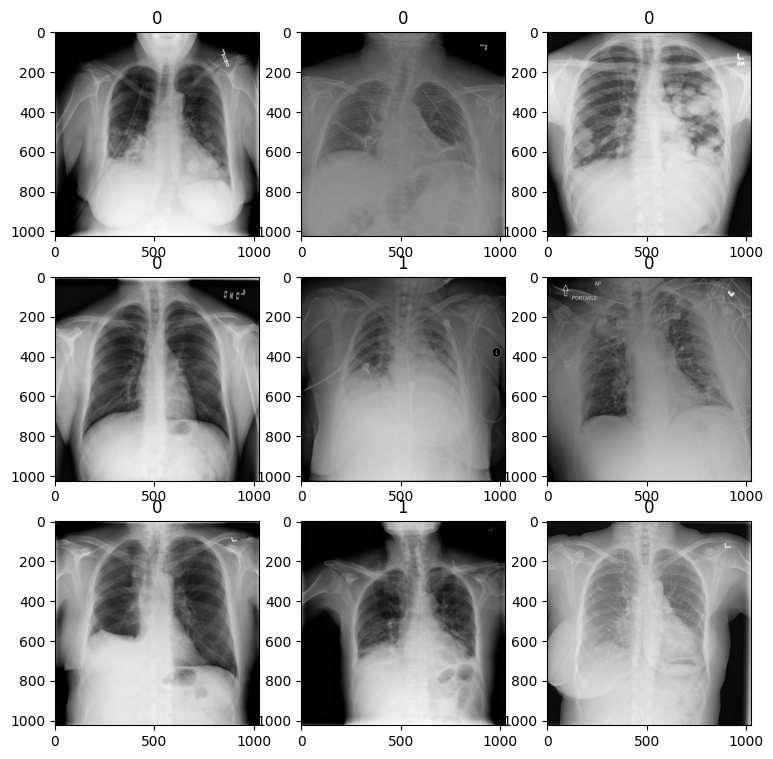

In [ ]:
fig, axis = plt.subplots(3, 3, figsize=(9, 9))
c=0
for i in range(3):
  for j in range(3):
    patient_id = labels.patientId.iloc[c]
    dcm_path = ROOT_PATH / patient_id
    dcm_path = dcm_path.with_suffix('.dcm')
    dcm = pydicom.dcmread(dcm_path).pixel_array

    label = labels["Target"].iloc[c]
    axis[i][j].imshow(dcm, cmap='gray')
    axis[i][j].set_title(label)
    c+=1


In [ ]:
sums, sums_squared = 0,0

for c, patient_id in enumerate(tqdm(labels.patientId)):
    patient_id = labels.patientId.iloc[c]
    dcm_path = ROOT_PATH / patient_id
    dcm_path = dcm_path.with_suffix('.dcm')
    dcm = pydicom.dcmread(dcm_path).pixel_array / 255

    dcm_array = cv2.resize(dcm, (224, 224)).astype(np.float32)

    label = labels["Target"].iloc[c]

    train_or_val = "train" if c < 24000 else "val"

    current_save_path = SAVE_PATH / train_or_val / str(label)
    current_save_path.mkdir(parents=True, exist_ok=True)

    # Save the processed numpy array as an .npy file
    np.save(current_save_path / f"{patient_id}.npy", dcm_array)

    normalizer = 224*224
    if train_or_val == "train":
        sums += np.sum(dcm_array)/normalizer
        sums_squared += (dcm_array**2).sum()/normalizer

  0%|          | 0/26684 [00:00<?, ?it/s]

In [ ]:
mean = sums/24000
std = (sums_squared/24000 - mean**2)**0.5
print(mean, std)

0.49039742 0.24794473


In [ ]:
ls /content/drive/MyDrive/rsna_data

'GCP Credits Request Link - RSNA.txt'     stage_2_sample_submission.csv
 processed/                               stage_2_test_images/
 rsna-pneumonia-detection-challenge.zip   stage_2_train_images/
 stage_2_detailed_class_info.csv          stage_2_train_labels.csv


In [ ]:
ls /content/drive/MyDrive/rsna_data/processed/

train/  val/


In [ ]:
!pip install torchmetrics
!pip install pytorch_lightning
import torch
import torchvision
from torchvision import transforms
import torchmetrics
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 26.4 MB/s eta 0:00:00


In [ ]:
def load_file(path):
  return np.load(path).astype(np.float32)

In [ ]:
train_transforms = transforms.Compose([
                                    transforms.ToTensor(),  # Convert numpy array to tensor
                                    transforms.Normalize(0.49, 0.248),  # Use mean and std from preprocessing notebook
                                    transforms.RandomAffine( # Data Augmentation
                                        degrees=(-5, 5), translate=(0, 0.05), scale=(0.9, 1.1)),
                                        transforms.RandomResizedCrop((224, 224), scale=(0.35, 1))

])

val_transforms = transforms.Compose([
                                    transforms.ToTensor(),  # Convert numpy array to tensor
                                    transforms.Normalize([0.49], [0.248]),  # Use mean and std from preprocessing notebook
])

In [ ]:
import os

print(os.path.exists("/content/drive/MyDrive/rsna_data/processed/train"))
print(os.listdir("/content/drive/MyDrive/rsna_data/processed"))

True
['train', 'val']


In [ ]:
train_dataset = torchvision.datasets.DatasetFolder(
    root="/content/drive/MyDrive/rsna_data/processed/train",
    loader=load_file,
    extensions="npy",
    transform=train_transforms
)

val_dataset = torchvision.datasets.DatasetFolder(
    root="/content/drive/MyDrive/rsna_data/processed/val",
    loader=load_file,
    extensions="npy",
    transform=val_transforms
)

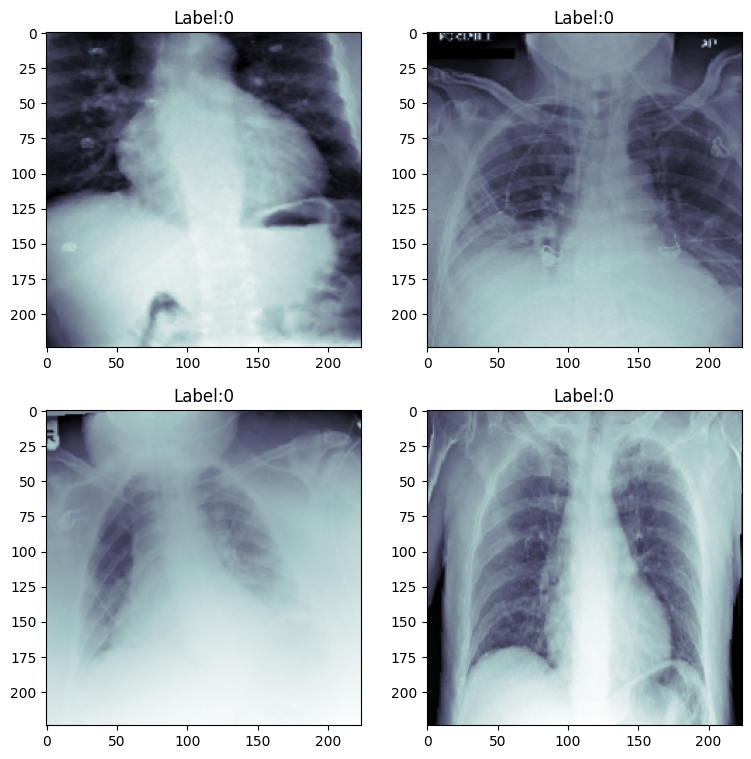

In [ ]:
fig, axis = plt.subplots(2, 2, figsize=(9, 9))
for i in range(2):
    for j in range(2):
        random_index = np.random.randint(0, 20000)
        x_ray, label = train_dataset[random_index]
        axis[i][j].imshow(x_ray[0], cmap="bone")
        axis[i][j].set_title(f"Label:{label}")


In [ ]:
batch_size = 32#TODO
num_workers = 2# TODO

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, num_workers=num_workers, shuffle=False)

print(f"There are {len(train_dataset)} train images and {len(val_dataset)} val images")

There are 24000 train images and 2684 val images


In [ ]:
np.unique(train_dataset.targets, return_counts=True), np.unique(val_dataset.targets, return_counts=True)

((array([0, 1]), array([18593,  5407])), (array([0, 1]), array([2079,  605])))

In [ ]:
class PneumoniaModel(pl.LightningModule):
    def __init__(self, weight=1):
        super().__init__()

        self.model = torchvision.models.resnet18()
        # change conv1 from 3 to 1 input channels
        self.model.conv1 = torch.nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        # change out_feature of the last fully connected layer (called fc in resnet18) from 1000 to 1
        self.model.fc = torch.nn.Linear(in_features=512, out_features=1)

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)
        self.loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight]))

        # simple accuracy computation
        self.train_acc = torchmetrics.Accuracy(task="binary", threshold=0.5)
        self.val_acc   = torchmetrics.Accuracy(task="binary", threshold=0.5)

        self.train_f1 = torchmetrics.F1Score(task="binary", threshold=0.5)
        self.val_f1   = torchmetrics.F1Score(task="binary", threshold=0.5)


    def forward(self, data):
        pred = self.model(data)
        return pred

    def training_step(self, batch, batch_idx):
      x_ray, label = batch
      label = label.float()

      pred = self(x_ray)[:, 0]
      loss = self.loss_fn(pred, label)

      self.train_acc.update(pred, label.int())

      self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=False)

      return loss

    def on_train_epoch_end(self):
      self.log("train_acc", self.train_acc.compute(), prog_bar=True)
      self.train_acc.reset()

    def validation_step(self, batch, batch_idx):
      x_ray, label = batch
      label = label.float()
      pred = self(x_ray)[:, 0]

      loss = self.loss_fn(pred, label)

      self.val_acc.update(pred, label.int())
      self.log("val_loss", loss, prog_bar=True)
      self.log("val_acc", self.val_acc, prog_bar=True)

      return loss


    def configure_optimizers(self):
        #Caution! You always need to return a list here (just pack your optimizer into one :))
        return [self.optimizer]


In [ ]:
from pytorch_lightning.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    monitor="val_loss",
    save_top_k=1,
    mode="min"
)

In [ ]:
callbacks=checkpoint_callback,


In [ ]:
model = PneumoniaModel()  # Instanciate the model

In [ ]:
trainer = pl.Trainer(
    accelerator="auto",
    devices=1,
    logger=TensorBoardLogger(save_dir="./logs"),
    log_every_n_steps=1,
    callbacks=[checkpoint_callback],
    max_epochs=1,
    limit_train_batches=10,
    limit_val_batches=5
)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [ ]:
trainer.fit(model, train_loader, val_loader)

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ ResNet            │ 11.2 M │ train │     0 │
│ 1 │ loss_fn   │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2 │ train_acc │ BinaryAccuracy    │      0 │ train │     0 │
│ 3 │ val_acc   │ BinaryAccuracy    │      0 │ train │     0 │
│ 4 │ train_f1  │ BinaryF1Score     │      0 │ train │     0 │
│ 5 │ val_f1    │ BinaryF1Score     │      0 │ train │     0 │
└───┴───────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44                                                                         
Modules in train mode: 73                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=1` reached.


In [ ]:
import pytorch_lightning as pl
import torchmetrics

print(pl.__version__)
print(torchmetrics.__version__)


2.6.0
1.8.2


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PneumoniaModel.load_from_checkpoint(
    "logs/lightning_logs/version_0/checkpoints/epoch=0-step=10.ckpt"
)
model.eval()
model.to(device)

PneumoniaModel(
  (model): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, trac

In [ ]:
import os

os.listdir("logs/lightning_logs/version_0/checkpoints")

['epoch=0-step=10.ckpt']

In [ ]:
TensorBoardLogger(save_dir="./logs")


In [ ]:
preds = []
labels = []

model.eval()
with torch.no_grad():
    for data, label in tqdm(val_dataset):
        data = data.to(device).float().unsqueeze(0)   # [1, C, H, W]
        logit = model(data)                           # [1, 1] or [1]
        prob = torch.sigmoid(logit)                   # probability

        preds.append(prob.squeeze().cpu())             # scalar
        labels.append(label)

preds = torch.stack(preds)      # shape: [N]
labels = torch.tensor(labels)   # shape: [N]



  0%|          | 0/2684 [00:00<?, ?it/s]

In [ ]:
preds = preds.int()
labels = labels.int()

acc = Accuracy(task="binary")(preds, labels)
precision = Precision(task="binary")(preds, labels)
recall = Recall(task="binary")(preds, labels)
cm = ConfusionMatrix(task="binary")(preds, labels)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Confusion Matrix:")
print(cm)


Accuracy: 0.7746
Precision: 0.0000
Recall: 0.0000
Confusion Matrix:
tensor([[2079,    0],
        [ 605,    0]])
